## Inteligencja Obliczeniowa w Analizie Danych Cyfrowych

### Projekt 4 - własne środowisko gymnasium: gra Climber

#### Autorzy: Kacper Garwoński, Paweł Gleindek (CWL02, czwartek 11:30)

Tematem czwartego mini-projektu było stworzenie własnego środowiska Gymnasium w postaci gry z ciągłą przestrzenią obserwacji lub dużą przestrzenią dyskretną. Należało także stworzyć agenta *reinforcement-learning*, który będzie skutecznie przechodził poziomy rozgrywki, a jego akcje w środowisku będą wskazywać na działanie według strategii, a nie losowe.

W swoim projekcie zaimplementowaliśmy autorską grę o nazwie **Climber**. Polega ona na wspinaczce - gracz wbijając kilof oraz wykorzystując wahanie skacze po planszy wspinając się. Jego celem jest dojście na samą górę planszy, do losowo ustawianego punktu. Podczas wspinaczki musi unikać spadających skał. Szerszy opis znajduje się w dalszej części sprawozdania.

### Import niezbędnych bibliotek

In [2]:
from typing import Any
import numpy as np
import pygame
import pymunk
from pymunk import pygame_util
from gymnasium import Env, spaces
from gymnasium.core import ObsType
import enum
from collections import deque
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor
import torch
import zipfile
import io
import time
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
import matplotlib.pyplot as plt
import pandas as pd
import math

### Opis implementacji gry

#### Klasa `ObjectCategory`

Pomocniczy typ enumeracyjny kodujący obiekty gry:

- gracz: 1
- ściana: 2
- skała: 4
- cel: 8

In [3]:
class ObjectCategory(enum.IntFlag):
    PLAYER = 1
    WALL = 2
    ROCK = 4
    TARGET = 8

#### Klasa `Climber`

Zasadnicza klasa dziedzicząca po `Env` opisująca logikę całej gry. Zawiera następujące funkcje:

- `__init__`: funkcja inicjalizująca (~konstruktor), odpowiada za ustawienie parametrów gry, m.in.:
    - typu renderowania,
    - częstotliwości renderowania spadających kamieni,
    - rozmiaru gracza, kamieni, celu,
    - siły grawitacji,
    - siły zamachu gracza;
- `step`: funkcja realizująca pojedynczą akcję agenta, odpowiada za jego ruch po planszy; w przypadku gry przez agenta RF wylicza nagrodę za ruch na podstawie zdefiniowanych parametrów (np. kara za uderzenie w skałę, bonus za dojście do celu)
- `render`: funkcja odpowiadająca za renderowanie planszy z grą;
- `close`: funkcja obsługująca zamknięcie programu;
- `reset`: funkcja obsługująca reset planszy po sukcesie gracza lub jego porażce w danej turze;
- `_generate_player_pos`: pomocnicza funkcja losowo generująca pozycję gracza na początku tury;
- `_generate_target_pos`: pomocnicza funkcja losowo generująca pozycję celu na początku tury;
- `_generate_rock_pos`: pomocnicza funkcja generująca losowo kolejne położenia spadających skał;
- `_create_target`: pomocnicza funkcja definiująca wygląd i zachowanie agenta na podstawie zadanych parametrów gry;
- `_create_player`: pomocnicza funkcja definiująca wygląd i zachowanie celu (na podstawie zadanych parametrów gry);
- `_create_walls`: pomocnicza funkcja definiująca ściany środowiska/planszy, po jakiej porusza się agent;
- `_create_pickaxe`: pomocnicza funkcja definiująca wygląd i zachowanie kilofa gracza na podstawie;
- `_create_rock`: pomocnicza funkcja definiująca wygląd i zachowanie spadającej skały na podstawie;
- `_get_obs`: kluczowa z punktu widzenia agenta funkcja, która zwraca mu stan jego obserwacji, m.in. jego pozycję, stan wbicia kilofa, wychylenie;
- `_rock_collision`: funkcja obsługująca zdarzenie polegające na zderzeniu agenta ze skałą;
- `_target_collision`: funkcja obsługująca zwycięstwo gracza (dojście do celu);

![Game Screen](game_screen.jpg "Widok gry")

In [4]:
def _get_relative_pos(body1: pymunk.Body, body2: pymunk.Body) -> tuple[float, float]:
    return  body1.position.x - body2.position.x, body1.position.y - body2.position.y

class Climber(Env):
    """
    Climber game environment for gymnasium. Observation space is continuous,
    same as action space. Number of rays used in ray-casting is hardcoded and
    is 12. Utilizes pymunk as the physics engine.
    """

    metadata = {
        'render_modes': ['human'],
        'fps' : 60,
        'map_settings' : {
            'width': 800,
            'height': 800,
        }
    }

    def __init__(self, render_mode = None, rock_every: float = 0, player_size = 15,
                 rock_size = 15, target_size = 15, rock_mass = 0.75, gravity = 450,
                 pickaxe_length = 50, swing_power = 650):
        self.target_body = None
        self.player_body = None
        self.draw_options = None
        self.clock = None
        self.window = None
        self.space = None
        self.walls = None
        self.target = None
        self.player = None
        self.joint = None
        self.prev_pos = None

        assert rock_every > 0
        assert render_mode in self.metadata['render_modes'] or render_mode is None

        self.render_mode = render_mode
        self.rock_every = rock_every
        self.action_space = spaces.Box(low=-1, high=1, shape=(2,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(18,),
                                            dtype=np.float32)
        self.hit_rock = False
        self.hit_target = False
        self.curr_step = 0
        self.max_steps = 10_000
        self.pickaxe_length = pickaxe_length
        self.gravity_level = gravity
        self.swing_power_multiplier = swing_power
        self.target_size = target_size
        self.player_size = player_size
        self.rock_size = rock_size
        self.rock_mass = rock_mass
        self.ray_distance = 200


    def step(self, action):
        pickaxe_val = action[0]
        player_force = action[1]

        self.prev_pos = self.player.body.position

        if pickaxe_val >= 0 and self.joint is None:
            self.joint = self._create_pickaxe()
            self.space.add(self.joint)

        elif pickaxe_val < 0 and self.joint:
            self.space.remove(self.joint)
            self.joint = None

        if self.joint is not None:
            force_x = player_force * self.swing_power_multiplier
            self.player.body.apply_force_at_local_point((force_x, 0), (0, 0))

        game_fps = self.metadata['fps']

        self.space.step(1 / game_fps)
        self.curr_step += 1
        obs = self._get_obs()

        reward = 0.0
        terminated = False
        truncated = False
        info = {}

        reward -= 0.01

        if self.hit_rock:
            reward -= 150
            terminated = True
            info["is_success"] = False

        elif self.curr_step >= self.max_steps:
            truncated = True

        elif self.hit_target:
            reward += 300
            terminated = True
            info["is_success"] = True

        else:
            prev_x, prev_y = self.prev_pos
            curr_x, curr_y = self.player.body.position
            target_x, target_y = self.target.body.position

            prev_relative_pos = np.linalg.norm(np.array([target_x - prev_x,
                                                         target_y - prev_y]))

            curr_relative_pos = np.linalg.norm(np.array([target_x - curr_x,
                                                         target_y - curr_y]))

            reward +=  prev_relative_pos - curr_relative_pos

        if self.curr_step % self.rock_every == 0:
            rock, rock_body = self._create_rock()
            self.space.add(rock_body)
            self.space.add(rock)

        return obs, reward, terminated, truncated, info

    def render(self):
        if self.render_mode != 'human':
            return

        if self.window is None:
            pygame.init()
            pygame.display.init()
            width = self.metadata['map_settings']['width']
            height = self.metadata['map_settings']['height']
            self.window = pygame.display.set_mode((width, height))
            self.clock = pygame.time.Clock()

            self.player_img_base = (pygame.image.load("character_green_walk_a.png")
                                    .convert_alpha())
            self.player_img_base = pygame.transform.scale(self.player_img_base,
                                                          (self.player_size * 2,
                                                           self.player_size * 2))

            self.rock_img_base = pygame.image.load("block_fall.png").convert_alpha()
            self.rock_img_base = pygame.transform.scale(self.rock_img_base,
                                                        (self.rock_size * 2,
                                                         self.rock_size * 2))

            self.target_img_base = pygame.image.load("ladybug_fly.png").convert_alpha()
            self.target_img_base = pygame.transform.scale(self.target_img_base,
                                                          (self.target_size * 2,
                                                           self.target_size * 2))

        self.window.fill((255, 255, 255))

        for wall in self.walls:
            p1 = (int(wall.a.x), int(wall.a.y))
            p2 = (int(wall.b.x), int(wall.b.y))
            pygame.draw.line(self.window, (50, 50, 50), p1, p2, int(wall.radius * 2))

        if self.joint is not None:
            p1 = (int(self.joint.anchor_a.x), int(self.joint.anchor_a.y))
            p2 = (int(self.player_body.position.x), int(self.player_body.position.y))
            pygame.draw.line(self.window, (139, 69, 19), p1, p2, 4)

        p_angle = math.degrees(-self.player_body.angle)
        p_img_rotated = pygame.transform.rotate(self.player_img_base, p_angle)
        p_rect = p_img_rotated.get_rect(center=(self.player_body.position.x,
                                                self.player_body.position.y))
        self.window.blit(p_img_rotated, p_rect.topleft)

        t_rect = self.target_img_base.get_rect(center=(self.target_body.position.x,
                                                       self.target_body.position.y))
        self.window.blit(self.target_img_base, t_rect.topleft)

        for shape in self.space.shapes:
            if shape.collision_type == ObjectCategory.ROCK:
                r_angle = math.degrees(-shape.body.angle)
                r_img_rotated = pygame.transform.rotate(self.rock_img_base, r_angle)
                r_rect = r_img_rotated.get_rect(center=(shape.body.position.x,
                                                        shape.body.position.y))
                self.window.blit(r_img_rotated, r_rect.topleft)

        pygame.display.flip()
        self.clock.tick(self.metadata['fps'])

    def close(self):
        if self.window is not None:
            pygame.quit()
            self.window = None
            self.clock = None

    def reset(
        self,
        *,
        seed: int | None = None,
        options: dict[str, Any] | None = None,
    ) -> tuple[ObsType, dict[str, Any]]:
        super().reset(seed=seed, options=options)

        self.space = pymunk.Space()

        self.target, self.target_body = self._create_target()
        self.player, self.player_body = self._create_player()
        self.prev_pos = self.player.body.position
        self.walls = self._create_walls()
        self.joint = None
        self.space.add(self.player, self.player_body, self.target, self.target_body,
                       *self.walls)
        self.space.gravity = (0, self.gravity_level)
        self.space.on_collision(ObjectCategory.PLAYER, ObjectCategory.ROCK,
                                begin = self._rock_collision)
        self.space.on_collision(ObjectCategory.PLAYER, ObjectCategory.TARGET,
                                begin = self._target_collision)
        self.curr_step = 0
        self.hit_rock = False
        self.hit_target = False

        return self._get_obs(), {}

    def _generate_player_pos(self) -> tuple[int, int]:
        rand_with_min = 50
        rand_with_max = max(self.metadata['map_settings']['width'] - 50, 100)

        player_height_pos = max(self.metadata['map_settings']['height'] - 50, 100)

        return (int(self.np_random.integers(low=rand_with_min, high=rand_with_max)),
                player_height_pos)

    def _generate_target_pos(self) -> tuple[int, int]:
        rand_with_min = 50
        rand_with_max = max(self.metadata['map_settings']['width'] - 50, 100)

        target_height_pos = 50

        return (int(self.np_random.integers(low=rand_with_min, high=rand_with_max)),
                target_height_pos)

    def _generate_rock_pos(self) -> tuple[int, int]:
        rand_with_min = 0
        rand_with_max = max(self.metadata['map_settings']['width'], 100)

        rock_height_pos = 50

        return (int(self.np_random.integers(low=rand_with_min, high=rand_with_max)),
                rock_height_pos)

    def _create_target(self) -> tuple[pymunk.Circle, pymunk.Body]:
        target_body = pymunk.Body(body_type=pymunk.Body.STATIC)
        target_body.position = self._generate_target_pos()
        target = pymunk.Circle(target_body, radius=self.target_size)
        target.filter = pymunk.ShapeFilter(categories=ObjectCategory.TARGET)
        target.sensor = True
        target.color = (0, 0, 0, 0)
        target.collision_type = ObjectCategory.TARGET

        return target, target_body

    def _create_player(self) -> tuple[pymunk.Circle, pymunk.Body]:
        player_body = pymunk.Body(mass=1,
                                  moment=pymunk.moment_for_circle(1, 0,
                                                                  self.player_size),
                                  body_type=pymunk.Body.DYNAMIC
                                  )

        player_body.position = self._generate_player_pos()

        player = pymunk.Circle(player_body, radius=self.player_size)
        player.color = (0, 0, 0, 0)

        player.filter = pymunk.ShapeFilter(categories=ObjectCategory.PLAYER)
        player.collision_type = ObjectCategory.PLAYER

        return player, player_body

    def _create_walls(self) -> list[pymunk.Segment]:
        map_height = self.metadata['map_settings']['height']
        map_width = self.metadata['map_settings']['width']

        floor = pymunk.Segment(self.space.static_body, (0, map_height),
                               (map_width, map_height), 10)
        ceiling = pymunk.Segment(self.space.static_body, (0, 0),
                                 (map_width, 0), 10)
        left_wall = pymunk.Segment(self.space.static_body, (0, 0),
                                   (0, map_height), 10)
        right_wall = pymunk.Segment(self.space.static_body, (map_width, 0),
                                    (map_width, map_height), 10)

        walls = [floor, ceiling, left_wall, right_wall]

        for wall in walls:
            wall.friction = 1.0
            wall.elasticity = 0.2
            wall.filter = pymunk.ShapeFilter(categories=ObjectCategory.WALL)

        return walls

    def _create_pickaxe(self) -> pymunk.PinJoint:
        pickaxe_x, pickaxe_y = (self.player.body.position.x,
                                self.player.body.position.y - self.pickaxe_length)

        joint = pymunk.PinJoint(
            self.space.static_body,
            self.player.body,
            (pickaxe_x, pickaxe_y),
            (0, 0)
        )

        return joint

    def _create_rock(self) -> tuple[pymunk.Circle, pymunk.Body]:
        rock_body = pymunk.Body(mass=self.rock_mass,
                                moment=pymunk.moment_for_circle(self.rock_mass,
                                                                0, self.rock_size),
                                body_type=pymunk.Body.DYNAMIC
                                )

        rock_body.position = self._generate_rock_pos()

        rock = pymunk.Circle(rock_body, radius=self.rock_size)
        rock.color = (0, 0, 0, 0)
        rock.filter = pymunk.ShapeFilter(categories=ObjectCategory.ROCK)
        rock.collision_type = ObjectCategory.ROCK

        return rock, rock_body

    def _get_obs(self):
        obs = np.zeros(18, dtype=np.float32)
        obs[0] = self.player.body.position.x
        obs[1] = self.player.body.position.y
        obs[2] = self.player.body.velocity.x
        obs[3] = self.player.body.velocity.y
        obs[4], obs[5] = _get_relative_pos(self.player.body, self.target.body)

        shape_filter = pymunk.ShapeFilter(categories=ObjectCategory.ROCK)
        rays = 12
        angle = 360 / rays

        for i in range(rays):

            rad_deg = np.deg2rad(angle * i)

            dx = np.cos(rad_deg) * self.ray_distance
            dy = np.sin(rad_deg) * self.ray_distance

            start_p = self.player.body.position
            end_p = (start_p.x + dx, start_p.y + dy)

            query = self.space.segment_query_first(start_p, end_p, 1,
                                                   shape_filter)

            if query is None:
                obs[6 + i] = self.ray_distance
            else:
                obs[6 + i] = query.alpha * self.ray_distance

        return obs

    def _rock_collision(self, arbiter, space, data):
        self.hit_rock = True
        print("GAME LOST - hit_rock")

    def _target_collision(self, arbiter, space, data):
        self.hit_target = True
        print("GAME WON - hit_target")

#### Funkcja `play_climber`

Funkcja uruchamiająca i wyświetlająca rozgrywkę

In [5]:
def play_climber():
    env = Climber(render_mode='human', rock_every=110, target_size=8,
                  rock_size=25, gravity=500, swing_power=600, pickaxe_length=60)
    obs, info = env.reset()
    env.render()
    pickaxe_active = False
    running = True

    print("Sterowanie:")
    print("- SPACJA: Wbij/Wyjmij kilof (Przełącznik)")
    print("- STRZAŁKA W LEWO: Siła w lewo")
    print("- STRZAŁKA W PRAWO: Siła w prawo")
    print("- ZAMKNIĘCIE OKNA: Wyjście")

    while running:
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                running = False
            elif event.type == pygame.KEYDOWN:
                if event.key == pygame.K_SPACE:
                    pickaxe_active = not pickaxe_active

        keys = pygame.key.get_pressed()
        force = 0.0
        if keys[pygame.K_LEFT]:
            force = -1.0
        if keys[pygame.K_RIGHT]:
            force = 1.0

        pickaxe_val = 1.0 if pickaxe_active else -1.0

        action = np.array([pickaxe_val, force], dtype=np.float32)

        obs, reward, terminated, truncated, info = env.step(action)

        env.render()

        if terminated or truncated:
            status = "WYGRANA!" if info.get("is_success") else "PORAŻKA (Kamień)"
            if truncated:
                status = "KONIEC CZASU"

            print(f"Koniec epizodu! Status: {status} | Ostatnia nagroda: {reward:.2f}")

            obs, info = env.reset()
            pickaxe_active = False

    env.close()

#### Gra

Uruchamiając poniższą komórkę można rozpocząć rozgrywkę i samemu zmierzyć się z wyzwaniem wspinaczki!

**Sterowanie**:

- spacja: wbij/wyjmij kilof (przełącznik)
- strzałka w lewo: siła w lewo
- strzałka w prawo: siła w prawo
- zamknięcie okna: wyjście

In [6]:
play_climber()

Sterowanie:
- SPACJA: Wbij/Wyjmij kilof (Przełącznik)
- STRZAŁKA W LEWO: Siła w lewo
- STRZAŁKA W PRAWO: Siła w prawo
- ZAMKNIĘCIE OKNA: Wyjście
GAME WON - hit_target
Koniec epizodu! Status: WYGRANA! | Ostatnia nagroda: 299.99
GAME LOST - hit_rock
Koniec epizodu! Status: PORAŻKA (Kamień) | Ostatnia nagroda: -150.01
GAME WON - hit_target
Koniec epizodu! Status: WYGRANA! | Ostatnia nagroda: 299.99
GAME LOST - hit_rock
Koniec epizodu! Status: PORAŻKA (Kamień) | Ostatnia nagroda: -150.01


### Trening agenta RF

Po stworzeniu ciekawej i angażującej gry przystąpiono do stworzenia i wytrenowania agenta Reinforcement Learning (uczącego się ze wzmocnieniem, tj. przez interakcje ze środowiskiem gry).

In [6]:
class EpisodeLoggerCallback(BaseCallback):
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.recent_rewards = deque(maxlen=10)
        self.episode_count = 0

    def _on_step(self) -> bool:
        if "episode" in self.locals["infos"][0]:
            ep_reward = self.locals["infos"][0]["episode"]["r"]
            ep_length = self.locals["infos"][0]["episode"]["l"]
            self.recent_rewards.append(ep_reward)
            self.episode_count += 1
            avg_reward = sum(self.recent_rewards) / len(self.recent_rewards)

            print(f"Epizod: {self.episode_count} | Kroki: {ep_length} | "
                  f"Nagroda: {ep_reward:.2f} | Średnia (ostatnie 10): {avg_reward:.2f}")

        return True

#### Funkcja `test_ppo`

Jest to podstawowy model treningu agenta RF. Model uczy się przez 350 000 kroków na domyślnych parametrach gry z nieco zmniejszoną częstotliwością spadania skał. Finalny model jest zapisywany, aby później można było go uruchomić i zobaczyć, jak sobie radzi. Cały proces nauki jest monitorowany przez TensorBoard; korzystając z odpowiedniego callbacku, metryki procesu nauki są zapisywane na bieżąco wraz z rozwojem agenta, aby później móc je zwizualizować i ocenić jego działanie.

In [7]:
def test_ppo():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    env = Climber(render_mode=None, rock_every=150)
    env = Monitor(env)

    model = PPO("MlpPolicy", env, verbose=0, device=device,
                tensorboard_log="./ppo_climber_tensorboard/")

    logger_callback = EpisodeLoggerCallback()

    model.learn(total_timesteps=500000, callback=logger_callback,
                tb_log_name="PPO_run_1")

    mean_reward, std_reward = evaluate_policy(model, env,
                                              n_eval_episodes=5)
    print(f"Średnia nagroda: {mean_reward}")

    model.save("ppo_climber_model")
    torch.save(model.policy.state_dict(), "climber_weights_only.pth")

    time.sleep(2)

    print("Model zapisany pomyślnie. Możesz zamknąć program.")

#### Funkcja `test_agent`

Jest to funkcja uruchamiająca wytrenowanego uprzednio i zapisanego agenta w środowisku gry. Jego zmagania można śledzić po ustawieniu parametru `render_mode` na `human`. Funkcja obsługuje też potencjalne konflikty i problemy z załadowaniem modelu, które mogą wynikać z różnic w wersjach bibliotek.

In [8]:
def test_agent(det):
    env = Climber(render_mode='human', rock_every=110)
    try:
        model = PPO.load("ppo_climber_model")
    except:
        model = PPO("MlpPolicy", env, verbose=1)

        model_path = "ppo_climber_model.zip"

        try:
            with zipfile.ZipFile(model_path, 'r') as archive:
                with archive.open('policy.pth') as weights_file:
                    buffer = io.BytesIO(weights_file.read())
                    state_dict = torch.load(buffer, map_location="cpu",
                                            weights_only=False)

                    model.policy.load_state_dict(state_dict)
                    print("Wagi wstrzyknięte pomyślnie!")
        except Exception as e:
            print(f"Błąd podczas ręcznego ładowania: {e}")
            return

    obs, info = env.reset()

    env.render()

    running = True
    while running:
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                running = False

        if not running:
            break

        action, _states = model.predict(obs, deterministic=det)
        obs, reward, terminated, truncated, info = env.step(action)

        env.render()

        if terminated or truncated:
            obs, info = env.reset()

    env.close()

### Nauka i analiza działania

Agent był szkolony przez 500 000 kroków ze skałami spadającymi z częstotliwością 150.

In [13]:
test_ppo()

In [19]:
test_agent(False)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wagi wstrzyknięte pomyślnie!
GAME WON - hit_target
GAME WON - hit_target
GAME WON - hit_target
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME WON - hit_target
GAME WON - hit_target
GAME WON - hit_target
GAME WON - hit_target
GAME LOST - hit_rock


Z powyższych danych i obserwacji wynika, że agent w trybie probabilistycznym radzi sobie całkiem dobrze, z 10 zapisanych rozgrywek udało mu się wygrać aż 7. Sprawnie wspina się do celu, czasami udaje mu się też uniknąć nadlatujących kamieni.

In [20]:
test_agent(True)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wagi wstrzyknięte pomyślnie!
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock


Agent w trybie deterministycznym, wybierając średnią najlepszą akcję, jest kompletnie bezradny - stoi w miejscu delikatnie się bujając, albo wykonuje losowe skoki. Widać więc, że proces nauki nie zapewnił mu zdobycia odpowiedniej wiedzy, która kazałaby mu się wspinać w stronę celu.

#### Wyniki

Proces nauki został zwizualizowany z użyciem danych z TensorBoard'a i biblioteki matplotlib.

In [37]:
def plot_graph(x, y, x_label, y_label, name):
    plt.plot(x,y)
    plt.title(name)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.grid(True)
    plt.show()

#### Wykres średniej nagrody agenta w kolejnych epizodach

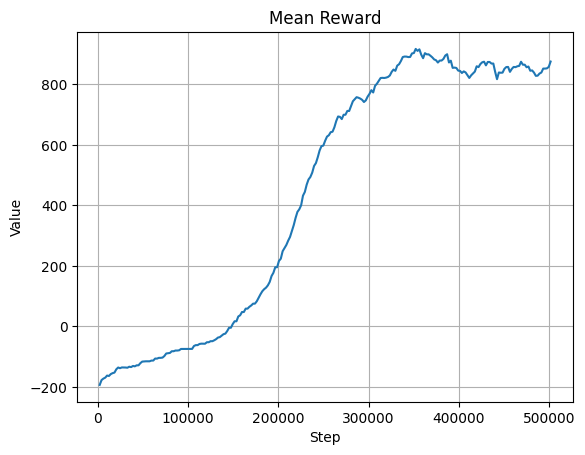

In [73]:
df_ppo_ep_rew_mean = pd.read_csv("data/ppo_rew_mean.csv")
plot_graph(df_ppo_ep_rew_mean['Step'], df_ppo_ep_rew_mean['Value'],
           'Step', 'Value', 'Mean Reward')

Na wykresie widać wyraźny trend rosnący, który w ostatnich fazach ulega spłaszczeniu. Oznacza to poprawny, stabilny proces nauki agenta, który staje się coraz lepszy w przechodzeniu tur gry, aż w końcu stabilizuje się na poziomie średniej nagrody równej ok. 800-900.

#### Wykres poziomu zwycięstw

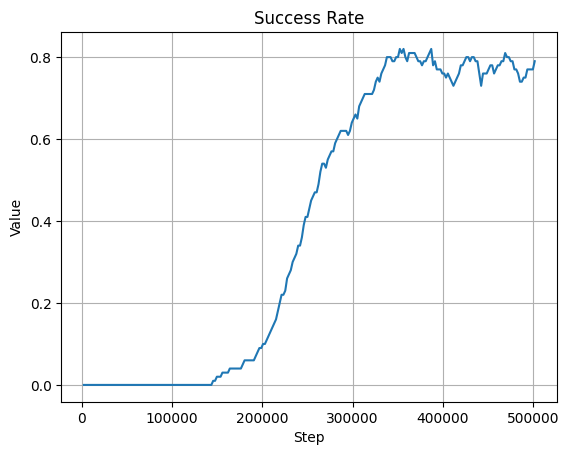

In [14]:
df_ppo_success_rate = pd.read_csv("data/ppo_success_rate.csv")
plot_graph(df_ppo_success_rate['Step'], df_ppo_success_rate['Value'],
           'Step', 'Value', 'Success Rate')

Wykres skuteczności agenta również wskazuje na poprawny przebieg procesu uczenia. Po 150 000 kroków agent zaczął odnosić pierwsze sukcesy, które po kolejnych etapach nauki doprowadziły go do ustabilizowania się na poziomie ok. 80% zwycięstw.

#### Wykres efektywności agenta

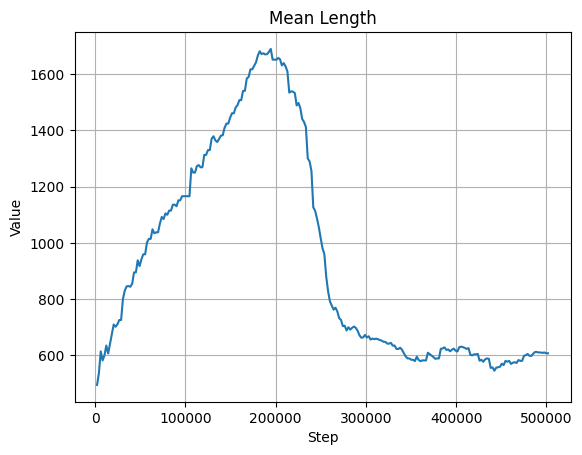

In [74]:
df_ppo_len_mean = pd.read_csv("data/ppo_len_mean.csv")
plot_graph(df_ppo_len_mean['Step'], df_ppo_len_mean['Value'],
           'Step', 'Value', 'Mean Length')

Wykres ten obrazuje średnią długość epizodu. Wartość początkowo rośnie, gdy agent nie jest jeszcze dobrze wytrenowany, jednak potem zaczyna spadać i stabilizuje się na poziomie ok 600. Przy jednoczesnym wzroście nagrody oznacza to, że uczy się docierać do celu najkrótszą drogą.

#### Wykres `value loss` - stabilność agenta

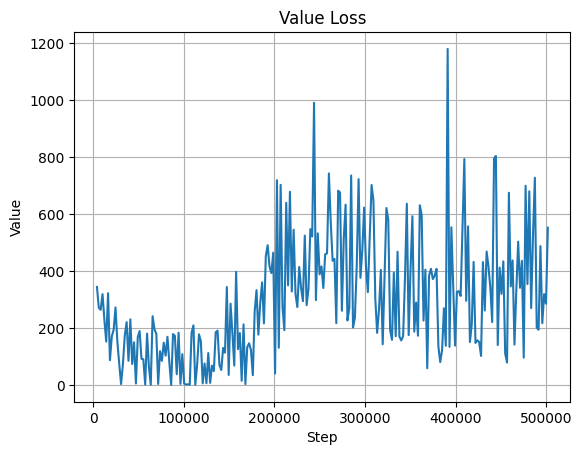

In [20]:
df_ppo_value_loss = pd.read_csv("data/ppo_value_loss.csv")
plot_graph(df_ppo_value_loss['Step'], df_ppo_value_loss['Value'],
           'Step', 'Value', 'Value Loss')

Na wykresie stabilności agenta i jego procesu nauki widać duże skoki wartości na przestrzeni wszystkich 500 000 kroków. Jest to związane z dużymi wahaniami kar i nagród, jakie zostały zastosowane w funkcji ewaluacyjnej.

#### Wykres jakości predykcji

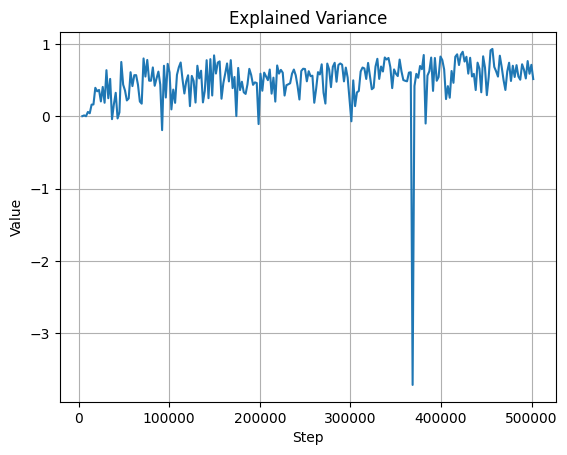

In [21]:
df_ppo_explained_variance = pd.read_csv("data/ppo_explained_variance.csv")
plot_graph(df_ppo_explained_variance['Step'], df_ppo_explained_variance['Value'],
           'Step', 'Value', 'Explained Variance')

Również tutaj - w stabilności i jakości decyzji podejmowanych przez agenta - widać duże wahania. Przekłada się to na duży procent sytuacji, w których model zgaduje, zamiast poruszać się zgodnie z logiką.

### Curriculum Learning

Wobec bardzo nieskutecznej nauki modelu dla podejścia deterministycznego w standardowym trybie oraz niestabilności wykryte w procesie uczenia zdecydowano się na podjęcie metody *curriculum learning* - uczenia przyrostowego. Proces nauki podzielono na 3 etapy:

1. **Faza 1 (nauka podstaw):** praktycznie nie występują spadające skały, model ma za zadanie nauczyć się zmierzać do celu.
2. **Faza 2 (średnie zagęszczenie):** kamienie spadają z umiarkowaną częstotliwością, model ma za zadanie nauczyć się je omijać.
3. **Faza 3 (trudne warunki):** kamienie spadają z docelową częstotliwością, model ma się udoskonalić.

Zmianom uległy także kary i nagrody stosowane w funkcji ewaluacyjnej agenta - zostały odpowiednio zmniejszone celem uniknięcia zbyt dużych gradientów i wartości *loss*.

Ponadto rozszerzono obserwację agenta o kilka dodatkowych parametrów, takich jak jego prędkość kątowa i stan wbicia kilofa.

Zdecydowano się także na zastosowanie znormalizowanego środowiska wektorowego, co ma za zadanie znormalizowanie wartości położenia agenta, aby sieć odpowiadająca za podejmowane przez niego decyzje nie otrzymywała zbyt wysokich wartości, co również mogło mieć negatywny wpływ na proces uczenia.

Dostrojono również hiperparametry nauki, zwłaszcza `gamma` i `ent_coef`, które bezpośrednio odpowiadają za proces nauki agenta.

In [9]:
def test_train_with_curriculum():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    def make_env(rock_val):
        env = Climber(render_mode=None, rock_every=rock_val)
        return Monitor(env)

    print("--- Faza 1: Nauka podstaw ---")
    venv = DummyVecEnv([lambda: make_env(1000)])
    venv = VecNormalize(venv, norm_obs=True, norm_reward=True, clip_obs=10.)

    model = PPO(
        "MlpPolicy",
        venv,
        verbose=0,
        tensorboard_log="./ppo_climber_tensorboard/",
        learning_rate=5e-5,
        n_steps=4096,
        batch_size=128,
        n_epochs=15,
        gamma=0.98,
        ent_coef=0.1,
        clip_range=0.1,
        device=device
    )
    model.learn(total_timesteps=250000, tb_log_name="phase_1")

    print("--- Faza 2: Średnie zagęszczenie ---")
    venv.venv = DummyVecEnv([lambda: make_env(300)])
    venv.reset()
    model.set_env(venv)
    model.learn(total_timesteps=250000, tb_log_name="phase_2", reset_num_timesteps=False)

    print("--- Faza 3: Trudne warunki ---")
    venv.venv = DummyVecEnv([lambda: make_env(110)])
    venv.reset()
    model.set_env(venv)
    model.learn(total_timesteps=350000, tb_log_name="phase_3", reset_num_timesteps=False)

    model.save("ppo_climber_model")
    venv.save("vec_normalize.pkl")
    torch.save(model.policy.state_dict(), "climber_weights_only.pth")

    print("Model i statystyki zapisane.")

In [10]:
def test_agent_curriculum(det, rock_every=110, player_size=15, rock_size=15,
                          target_size=15, rock_mass=0.75, gravity=450,
                          pickaxe_length=50, swing_power=650):

    env = Climber(render_mode='human', rock_every=rock_every, player_size=player_size,
                  rock_size=rock_size, target_size=target_size, rock_mass=rock_mass,
                  gravity=gravity, pickaxe_length=pickaxe_length, swing_power=swing_power)
    venv = DummyVecEnv([lambda: env])

    try:
        venv = VecNormalize.load("vec_normalize.pkl", venv)
        venv.training = False
        venv.norm_reward = False
    except Exception as e:
        print(f"Błąd ładowania: {e}")
        return

    try:
        model = PPO.load("ppo_climber_model", env=venv)
    except:
        model = PPO("MlpPolicy", venv, verbose=1)

        model_path = "ppo_climber_model.zip"

        try:
            with zipfile.ZipFile(model_path, 'r') as archive:
                with archive.open('policy.pth') as weights_file:
                    buffer = io.BytesIO(weights_file.read())
                    state_dict = torch.load(buffer, map_location="cpu",
                                            weights_only=False)

                    model.policy.load_state_dict(state_dict)
                    print("Wagi wstrzyknięte pomyślnie!")
        except Exception as e:
            print(f"Błąd podczas ręcznego ładowania: {e}")
            return

    obs = venv.reset()
    env.render()
    running = True
    while running:
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                running = False

        if not running:
            break

        action, _states = model.predict(obs, deterministic=det)
        obs, reward, dones, info = venv.step(action)

        env.render()

    env.close()

In [11]:
def new_init(self, render_mode = None, rock_every: float = 0, player_size = 15,
             rock_size = 15, target_size = 15, rock_mass = 0.75, gravity = 450,
             pickaxe_length = 50, swing_power = 650):
    self.target_body = None
    self.player_body = None
    self.draw_options = None
    self.clock = None
    self.window = None
    self.space = None
    self.walls = None
    self.target = None
    self.player = None
    self.joint = None
    self.prev_pos = None

    assert rock_every > 0

    assert render_mode in self.metadata['render_modes'] or render_mode is None

    self.render_mode = render_mode
    self.rock_every = rock_every

    self.action_space = spaces.Box(low=-1, high=1, shape=(2,), dtype=np.float32)
    self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(22,),
                                        dtype=np.float32)

    self.hit_rock = False
    self.hit_target = False
    self.curr_step = 0
    self.max_steps = 10_000
    self.pickaxe_length = pickaxe_length
    self.gravity_level = gravity
    self.swing_power_multiplier = swing_power
    self.target_size = target_size
    self.player_size = player_size
    self.rock_size = rock_size
    self.rock_mass = rock_mass
    self.ray_distance = 200

def new_step(self, action):
    pickaxe_val = action[0]
    player_force = action[1]

    self.prev_pos = self.player.body.position

    if pickaxe_val > 0.5 and self.joint is None:
        self.joint = self._create_pickaxe()
        self.space.add(self.joint)
    elif pickaxe_val < -0.5 and self.joint:
        self.space.remove(self.joint)
        self.joint = None

    force_x = player_force * self.swing_power_multiplier
    if self.joint is not None:
        self.player.body.apply_force_at_local_point((force_x, 0), (0, 0))
    else:
        self.player.body.apply_force_at_local_point((force_x * 0.2, 0), (0, 0))

    game_fps = self.metadata['fps']

    self.space.step(1 / game_fps)
    self.curr_step += 1
    obs = self._get_obs()

    reward = 0.0
    terminated = False
    truncated = False
    info = {}

    reward -= 0.001

    if self.hit_rock:
        reward -= 2.0
        terminated = True
        info["is_success"] = False

    elif self.hit_target:
        reward += 20.0
        terminated = True
        info["is_success"] = True

    elif self.curr_step >= self.max_steps:
        truncated = True

    else:
        prev_dist = np.linalg.norm(self.prev_pos - self.target.body.position)
        curr_dist = np.linalg.norm(self.player.body.position
                                   - self.target.body.position)

        reward += (prev_dist - curr_dist) * 0.1
        reward += (self.prev_pos.y - self.player.body.position.y) * 0.05

        if self.joint is not None:
            reward += 0.01

        reward += (self.player.body.position.y / 1000) * 0.01
        reward -= abs(self.player.body.angular_velocity) * 0.05

    if self.curr_step % self.rock_every == 0:
        rock, rock_body = self._create_rock()
        self.space.add(rock_body)
        self.space.add(rock)

    return obs, reward, terminated, truncated, info

def new_reset(self, *, seed: int | None = None,
              options: dict[str, Any] | None = None, ) \
        -> tuple[ObsType, dict[str, Any]]:
    Env.reset(self, seed=seed, options=options)

    self.space = pymunk.Space()

    self.target, self.target_body = self._create_target()
    self.player, self.player_body = self._create_player()
    self.prev_pos = self.player.body.position
    self.walls = self._create_walls()
    self.joint = None

    self.space.add(self.player, self.player_body, self.target, self.target_body,
                   *self.walls)
    self.space.gravity = (0, self.gravity_level)
    self.space.on_collision(ObjectCategory.PLAYER, ObjectCategory.ROCK,
                            begin = self._rock_collision)
    self.space.on_collision(ObjectCategory.PLAYER, ObjectCategory.TARGET,
                            begin = self._target_collision)

    self.curr_step = 0
    self.hit_rock = False
    self.hit_target = False

    self.space.gravity = (0, self.gravity_level)
    self.space.damping = 0.7

    return self._get_obs(), {}

def new_create_pickaxe(self) -> pymunk.PinJoint:
    pos = self.player.body.position
    anchor_point = (pos.x, pos.y - self.pickaxe_length)

    joint = pymunk.PinJoint(
        self.space.static_body,
        self.player.body,
        anchor_point,
        (0, 0)
    )
    return joint

def new_get_obs(self):
    obs = np.zeros(22, dtype=np.float32)

    obs[0] = self.player.body.position.x / 800.0
    obs[1] = self.player.body.position.y / 1000.0

    obs[2] = self.player.body.velocity.x / 500.0
    obs[3] = self.player.body.velocity.y / 500.0

    dx, dy = _get_relative_pos(self.player.body, self.target.body)
    obs[4] = dx / 800.0
    obs[5] = dy / 1000.0

    shape_filter = pymunk.ShapeFilter(categories=ObjectCategory.ROCK)
    rays = 12
    angle = 360 / rays

    for i in range(rays):
        rad_deg = np.deg2rad(angle * i)

        dx = np.cos(rad_deg) * self.ray_distance
        dy = np.sin(rad_deg) * self.ray_distance

        start_p = self.player.body.position
        end_p = (start_p.x + dx, start_p.y + dy)

        query = self.space.segment_query_first(start_p, end_p, 1, shape_filter)

        if query is None:
            obs[6 + i] = 1.0
        else:
            obs[6 + i] = query.alpha

    obs[18] = 1.0 if self.joint is not None else 0.0

    angle = self.player.body.angle
    obs[19] = np.sin(angle)
    obs[20] = np.cos(angle)

    obs[21] = self.player.body.angular_velocity / 10.0

    return obs

In [12]:
Climber.__init__ = new_init
Climber.step = new_step
Climber.reset = new_reset
Climber._create_pickaxe = new_create_pickaxe
Climber._get_obs = new_get_obs

In [14]:
test_train_with_curriculum()

In [66]:
test_agent_curriculum(False)

Using cpu device
Wagi wstrzyknięte pomyślnie!
GAME WON - hit_target
GAME WON - hit_target
GAME WON - hit_target
GAME WON - hit_target
GAME LOST - hit_rock
GAME WON - hit_target
GAME WON - hit_target
GAME WON - hit_target
GAME WON - hit_target
GAME WON - hit_target


Model wytrenowany przyrostowo bardzo dobrze radzi sobie z grą w trybie probabilistycznym. Na 10 rozegranych partii poległ tylko raz. Sprawnie omija kamienie i szybko zbliża się do celu.

In [68]:
test_agent_curriculum(True)

Using cpu device
Wagi wstrzyknięte pomyślnie!
GAME WON - hit_target
GAME WON - hit_target
GAME WON - hit_target
GAME WON - hit_target
GAME LOST - hit_rock
GAME WON - hit_target
GAME WON - hit_target
GAME LOST - hit_rock
GAME WON - hit_target
GAME WON - hit_target


Model działający w trybie deterministycznym również działa bardzo dobrze. Widać w jego działaniu logikę poruszania się ku celowi możliwie szybką drogą. Udaje mu się także omijać spadające skały. Nie porusza się tak szybko jak agent probabilistyczny, niemniej praktycznie zawsze (tu - w 8 przypadkach na 10) udaje mu się dobrzeć do celu.

#### Wyniki

Proces nauki został zwizualizowany z użyciem danych z TensorBoard'a i biblioteki matplotlib.

#### Wykres średniej nagrody agenta w kolejnych epizodach

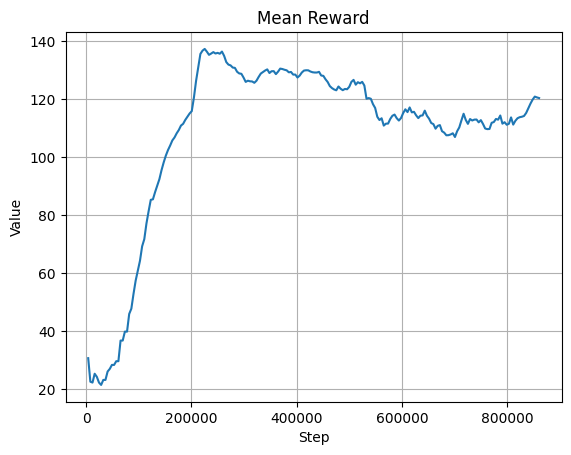

In [70]:
df_cl_rew_mean = pd.concat([pd.read_csv("data/cl_rew_mean_1.csv"),
                            pd.read_csv("data/cl_rew_mean_2.csv"),
                            pd.read_csv("data/cl_rew_mean_3.csv")])
plot_graph(df_cl_rew_mean['Step'], df_cl_rew_mean['Value'],
           'Step', 'Value', 'Mean Reward')

Wykres średniej nagrody agenta wygląda bardzo poprawnie. W 1 fazie nauki, przy braku przeszkód, agent osiągał wiele zwycięstw, więc wartość ta szybko rosła. W kolejnych 2 fazach napotkawszy skały średnia nagroda spada, ale dość nieznacznie. Cały czas utrzymuje się na poziomie między 110 a 130 (po przeskalowaniu parametrów kary i nagrody). Stabilizacja wykresu na wysokim poziomie dowodzi dobrej skuteczności agenta.

#### Wykres poziomu zwycięstw

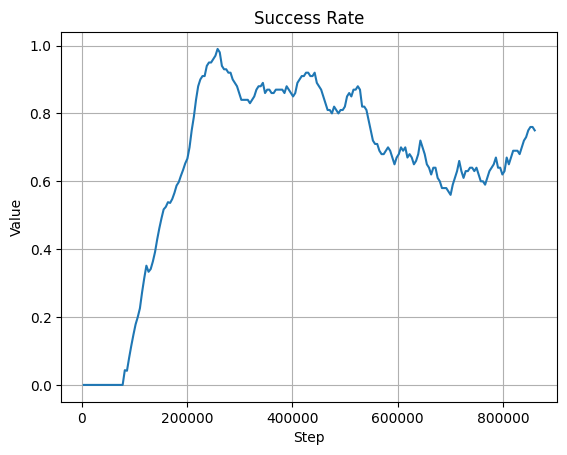

In [72]:
df_cl_success_rate = pd.concat([pd.read_csv("data/cl_success_rate_1.csv"),
                                pd.read_csv("data/cl_success_rate_2.csv"),
                                pd.read_csv("data/cl_success_rate_3.csv")])
plot_graph(df_cl_success_rate['Step'], df_cl_success_rate['Value'],
           'Step', 'Value', 'Success Rate')

Wykres ten jest komplementarny z powyższym wykresem średniej nagrody. W 1 fazie agent osiąga niemal 100% skuteczności, które następnie przez obecność kamieni spada do poziomu ok. 85% w 2 fazie, a potem do ok. 80% w fazie 3. Poziom ten jest już stabilny i zostaje zachowany w dalszych rozgrywkach agenta.

#### Wykres efektywności agenta

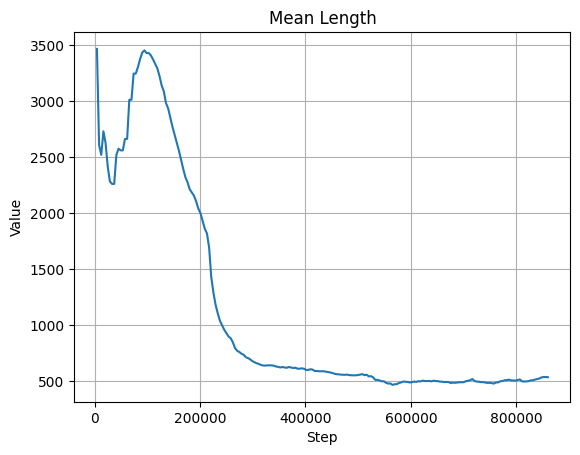

In [75]:
df_cl_len_mean = pd.concat([pd.read_csv("data/cl_len_mean_1.csv"),
                            pd.read_csv("data/cl_len_mean_2.csv"),
                            pd.read_csv("data/cl_len_mean_3.csv")])
plot_graph(df_cl_len_mean['Step'], df_cl_len_mean['Value'],
           'Step', 'Value', 'Mean Length')

Wykres efektywności agenta również potwierdza dobry poziom jego nauki. Po początkowych fluktuacjach czas trwania epizodu gwałtownie maleje aż do poziomu ok. 500 (który jest też niższy od uzyskanego w standardowym trybie uczenia). Oznacza to, że agent porusza się do celu możliwie najkrótszą trasą.

#### Wykres `value loss` - stabilność agenta

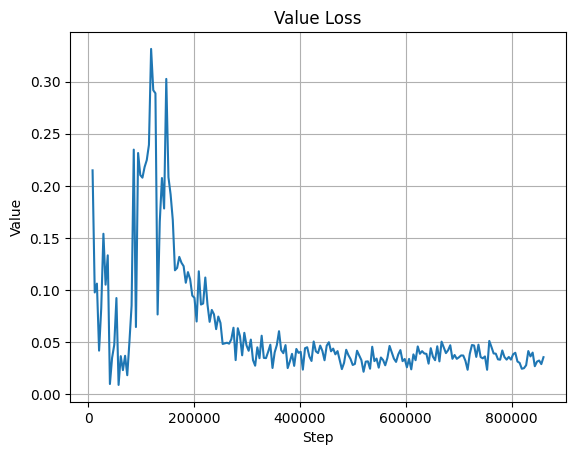

In [76]:
df_cl_value_loss = pd.concat([pd.read_csv("data/cl_value_loss_1.csv"),
                              pd.read_csv("data/cl_value_loss_2.csv"),
                              pd.read_csv("data/cl_value_loss_3.csv")])
plot_graph(df_cl_value_loss['Step'], df_cl_value_loss['Value'],
           'Step', 'Value', 'Value Loss')

Wykres wartości funkcji straty pokazuje znaczącą poprawę względem początkowego, bazowego procesu nauki. Początkowo występujące wahania są nieodłącznym elementem treningu, jednak i one nie były zbyt duże, a ponadto szybko się ustabilizowały na bardzo niskim poziomie rzędu 0.04-0.05.

#### Wykres wartości funkcji straty

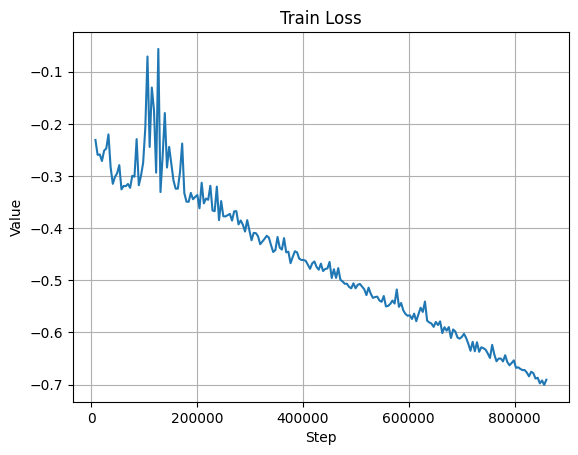

In [77]:
df_cl_loss = pd.concat([pd.read_csv("data/cl_loss_1.csv"),
                        pd.read_csv("data/cl_loss_2.csv"),
                        pd.read_csv("data/cl_loss_3.csv")])
plot_graph(df_cl_loss['Step'], df_cl_loss['Value'],
           'Step', 'Value', 'Train Loss')

Również wykres treningowych wartości funkcji straty pokazuje niemal liniową zbieżność modelu w procesie jego nauki.

### Podsumowanie

Zastosowanie metody uczenia przyrostowego, w którym model uczył się najpierw bez spadających kamieni, a później z nimi, w połączeniu z modyfikacjami jego obserwacji i wartości kar oraz nagród przyczyniło się do znacznej poprawy jego skuteczności. Zarówno model deterministyczny, jak i probabilistyczny bardzo dobrze radzą sobie w środowisku gry Climber. Proces nauki był stabilny i zbieżny do zadowalającego poziomu działania agenta.

### Eksperymenty z AI

W ramach ostatniej części analizy sprawdzono jak będzie działał wytrenowany agent przy zmienionych parametrach rozgrywki.

#### Eksperyment 1 - zwiększenie częstotliwości spadania skał

In [83]:
test_agent_curriculum(False, rock_every=80)

Using cpu device
Wagi wstrzyknięte pomyślnie!
GAME LOST - hit_rock
GAME WON - hit_target
GAME WON - hit_target
GAME WON - hit_target
GAME WON - hit_target
GAME LOST - hit_rock
GAME WON - hit_target
GAME WON - hit_target
GAME WON - hit_target
GAME LOST - hit_rock


In [84]:
test_agent_curriculum(True, rock_every=75)

Using cpu device
Wagi wstrzyknięte pomyślnie!
GAME WON - hit_target
GAME LOST - hit_rock
GAME WON - hit_target
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME WON - hit_target
GAME WON - hit_target
GAME WON - hit_target
GAME LOST - hit_rock
GAME WON - hit_target


Jak widać, zwiększenie częstotliwości spadania skał utrudniło agentowi zadanie (zgodnie z przewidywaniami), wobec czego nieco spadła jego skuteczność. Mimo wszystko w większości przypadków udawało mu się dotrzeć do celu i omijać niektóre kamienie.

#### Eksperyment 2 - większy rozmiar skał

In [85]:
test_agent_curriculum(False, rock_size=30)

Using cpu device
Wagi wstrzyknięte pomyślnie!
GAME WON - hit_target
GAME LOST - hit_rock
GAME WON - hit_target
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME WON - hit_target
GAME WON - hit_target
GAME LOST - hit_rock


In [86]:
test_agent_curriculum(True, rock_size=30)

Using cpu device
Wagi wstrzyknięte pomyślnie!
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME WON - hit_target
GAME WON - hit_target
GAME LOST - hit_rock
GAME WON - hit_target
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock


Dwukrotne zwiększenie rozmiaru skał okazało się dla agenta jeszcze trudniejszym zadaniem. Przez wielkość spadających kamieni trudniej było je z wyprzedzeniem omijać, co przełożyło się na jeszcze większy spadek skuteczności. Mimo wszystko czasami agentowi udawało się dotrzeć na szczyt (zwłaszcza w trybie probabilistycznym).

#### Eksperyment 3 - dłuższe ramię kilofa

In [87]:
test_agent_curriculum(False, pickaxe_length=70)

Using cpu device
Wagi wstrzyknięte pomyślnie!
GAME LOST - hit_rock
GAME WON - hit_target
GAME WON - hit_target
GAME WON - hit_target
GAME WON - hit_target
GAME LOST - hit_rock
GAME WON - hit_target
GAME LOST - hit_rock
GAME WON - hit_target
GAME WON - hit_target


In [88]:
test_agent_curriculum(True, pickaxe_length=70)

Using cpu device
Wagi wstrzyknięte pomyślnie!
GAME WON - hit_target
GAME WON - hit_target
GAME WON - hit_target
GAME WON - hit_target
GAME WON - hit_target
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME WON - hit_target
GAME LOST - hit_rock


Z obserwacji wynika, że zwiększenie długości kilofa poprawia działanie agenta deterministycznego, który dzięki temu i swoim stabilnym krokom w stronę celu szybciej się do niego zbliża. W przypadku probabilistycznym zmiana ta wprowadza nieco zamieszania.

#### Eksperyment 4 - zwiększona siła agenta

In [89]:
test_agent_curriculum(False, swing_power=800)

Using cpu device
Wagi wstrzyknięte pomyślnie!
GAME WON - hit_target
GAME WON - hit_target
GAME WON - hit_target
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME WON - hit_target
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME WON - hit_target
GAME WON - hit_target


In [90]:
test_agent_curriculum(True, swing_power=800)

Using cpu device
Wagi wstrzyknięte pomyślnie!
GAME LOST - hit_rock
GAME WON - hit_target
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME WON - hit_target
GAME WON - hit_target
GAME WON - hit_target
GAME WON - hit_target
GAME LOST - hit_rock


Zwiększenie siły agenta wprowadza nieco zamieszania w działania agenta zarówno deterministycznego, jak i probabilistycznego; niemniej każdy z nich kieruje się w stronę celu i dość często udaje mu się do niego dotrzeć.

#### Eksperyment 5 - ustawienia mieszane

In [91]:
test_agent_curriculum(False, rock_size=25, rock_every=100, pickaxe_length=65,
                      swing_power=750)

Using cpu device
Wagi wstrzyknięte pomyślnie!
GAME WON - hit_target
GAME WON - hit_target
GAME WON - hit_target
GAME WON - hit_target
GAME LOST - hit_rock
GAME WON - hit_target
GAME WON - hit_target
GAME WON - hit_target
GAME LOST - hit_rock
GAME WON - hit_target


In [92]:
test_agent_curriculum(True, rock_size=25, rock_every=100, pickaxe_length=65,
                      swing_power=750)

Using cpu device
Wagi wstrzyknięte pomyślnie!
GAME WON - hit_target
GAME WON - hit_target
GAME WON - hit_target
GAME WON - hit_target
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME LOST - hit_rock
GAME WON - hit_target
GAME WON - hit_target


W warunkach zmieszanych i nieco losowych oba podejścia - deterministyczne i probabilistyczne - poradziły sobie bardzo przyzwoicie docierając w większości przypadków do celu.

### Podsumowanie

Widać wyraźnie, że modyfikacje parametrów gry mają realny wpływ na skuteczność działania agenta wytrenowanego w środowisku domyślnym. Większość z nich powoduje gorsze działanie, jednak widać w nich także potencjał na ulepszenie modeli. Aby działanie agenta było w pełni reprezentatywne musiałby on oczywiście zostać dotrenowany w zmodyfikowanym środowisku.